# Food Price Forecasting for Kenyan Markets 

## Business Understanding

Food prices in Kenya have experienced significant fluctuations in recent years, driven by factors such as changing weather patterns, rising transportation costs, inflation, currency fluctuations, and supply chain disruptions. Essential food commodities such as maize, beans, rice, tomatoes, and vegetables have shown substantial price volatility, affecting both urban and rural households.

The rising cost of food poses a major challenge to food security and household welfare. Consumers face reduced purchasing power as food expenditures account for a significant portion of household income. Farmers, traders, retailers, and policymakers also face difficulties in planning and decision-making due to uncertainty in future market prices.

Accurate forecasting of food prices can provide valuable insights for various stakeholders. Farmers can make informed production and storage decisions, traders can better manage inventory and pricing strategies, and policymakers can anticipate potential food shortages or inflationary pressures and implement appropriate interventions.

This project aims to analyze historical food price data from Kenyan markets and develop predictive models capable of forecasting future prices of selected food commodities. The project will focus on identifying price trends, seasonal patterns, and market variations while evaluating the effectiveness of different forecasting techniques. The resulting insights can contribute to improved planning, enhanced food security, and more data-driven decision-making within Kenya's food system.

### Project Objectives

* Analyze historical food price trends across Kenyan markets.
* Identify commodities with the highest price volatility.
* Explore seasonal and market-specific patterns in food prices.
* Develop and evaluate forecasting models for selected food commodities.
* Generate future price forecasts to support decision-making.
* Provide visualizations and insights that improve understanding of food price dynamics in Kenya.


## Data Understanding

The dataset used in this project is the World Food Programme (WFP) Food Prices Dataset for Kenya. The dataset contains historical market prices of various food commodities collected from different markets across the country over multiple years. The data provides information on the prices of staple foods such as maize, beans, rice, wheat flour, tomatoes, and other essential commodities consumed by Kenyan households.

The dataset is particularly suitable for food price analysis and forecasting because it captures temporal variations in market prices across different regions and commodities. These observations make it possible to identify trends, seasonal patterns, and periods of significant price volatility.

### Data Source

The data was obtained from the World Food Programme (WFP), an international humanitarian organization that monitors food prices to support food security analysis and policy formulation. The dataset contains market-level food price observations collected from various Kenyan markets.

### Expected Variables

The dataset may include variables such as:

* Date of observation
* Market name
* Commodity name
* Commodity category
* Unit of measurement
* Price
* Currency
* Administrative region

These variables provide information about when and where a commodity was sold and the corresponding market price at that time.

### Data Exploration Objectives

The initial exploration of the dataset will focus on:

* Determining the number of observations and variables.
* Identifying the available food commodities.
* Examining the geographic coverage of markets.
* Assessing data quality, including missing values and duplicate records.
* Understanding the distribution of food prices.
* Identifying trends and seasonal patterns in commodity prices.
* Evaluating price differences across markets and commodities.

### Potential Data Quality Issues

Several challenges may be encountered during data exploration and preprocessing:

* Missing values in price or market records.
* Inconsistent naming of commodities or markets.
* Differences in units of measurement.
* Outliers caused by unusual market conditions.
* Irregular time intervals between observations.

Addressing these issues will be essential to ensure reliable analysis and accurate forecasting results.

### Relevance to the Project

The dataset provides the historical information required to analyze food price behavior and develop forecasting models. By examining past price movements, the project aims to generate insights into food price dynamics and predict future price trends for selected commodities in Kenyan markets.


In [1]:
!pip install datasets


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


In [2]:
from datasets import load_dataset
import pandas as pd

# 1. Bypassing the metadata row-count check
ds = load_dataset(
    "electricsheepafrica/africa-wfp-food-prices-for-kenya", 
    verification_mode="no_checks"
)

# 2. Convert the Hugging Face splits into Pandas DataFrame
df_train = ds["train"].to_pandas()
df_test = ds["test"].to_pandas()
## 3. Combine them if you want to look at the whole dataset at once for exploration
df = pd.concat([df_train, df_test], ignore_index=True)
# 4. Now you can explore the DataFrame as usual
print(df.head())

/home/livvy/Documents/Quantam Analysis/.venv/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/datasets/electricsheepafrica/africa-wfp-food-prices-for-kenya/resolve/d4c653d29600a10e36857438cc250eb43df4887e/africa-wfp-food-prices-for-kenya.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since electricsheepafrica/africa-wfp-food-prices-for-kenya couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'default' at /home/livvy/.cache/huggingface/datasets/electricsheepafrica___africa-wfp-food-prices-for-kenya/default/0.0.0/d4c653d29600a10e36857438cc250eb43df4887e (last modified on Mon Jun  8 16:00:37 2026).


        date       admin1       admin2                      market  market_id  \
0 2025-06-15  Rift Valley      Turkana       Kalobeyei (Village 2)       3246   
1 2021-05-15  Rift Valley       Nakuru           Wakulima (Nakuru)       5669   
2 2017-09-15        Coast      Mombasa                     Mombasa        191   
3 2011-11-15  Rift Valley  Uasin Gishu  Eldoret town (Uasin Gishu)        185   
4 2011-03-15       Nyanza       Kisumu                      Kisumu        186   

   latitude  longitude            category       commodity  commodity_id  \
0      3.76      34.75  miscellaneous food            Salt           185   
1     -0.30      36.08     pulses and nuts  Beans (kidney)           180   
2     -4.05      39.67     pulses and nuts     Beans (dry)           262   
3      0.52      35.28     pulses and nuts           Beans            50   
4     -0.10      34.75  cereals and tubers         Sorghum            65   

    unit         priceflag  pricetype currency    price 

In [3]:
# Info of the dataset
print("\n--- DATASET SUMMARY ---")
df.info()
print("\n--- STATISTICAL SUMMARY ---")
df.describe()


--- DATASET SUMMARY ---
<class 'pandas.DataFrame'>
RangeIndex: 17814 entries, 0 to 17813
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           17814 non-null  datetime64[ns]
 1   admin1         17772 non-null  str           
 2   admin2         17772 non-null  str           
 3   market         17814 non-null  str           
 4   market_id      17814 non-null  int64         
 5   latitude       17772 non-null  float64       
 6   longitude      17772 non-null  float64       
 7   category       17814 non-null  str           
 8   commodity      17814 non-null  str           
 9   commodity_id   17814 non-null  int64         
 10  unit           17814 non-null  str           
 11  priceflag      17814 non-null  str           
 12  pricetype      17814 non-null  str           
 13  currency       17814 non-null  str           
 14  price          17814 non-null  float64       
 15  usdpr

,date,market_id,latitude,longitude,commodity_id,price,usdprice
count,17814,17814.000000,17772.000000,17772.000000,17814.000000,17814.000000,17814.000000
mean,2021-01-08 02:26:52.664196608,3979.943977,0.718476,36.987365,298.689065,1360.097445,12.477814
min,2006-01-15 00:00:00,184.000000,-4.660000,34.360000,50.000000,5.000000,0.039000
25%,2020-06-15 00:00:00,1850.000000,-1.270000,34.850000,67.000000,68.000000,0.600000
50%,2022-05-15 00:00:00,3254.000000,0.350000,36.780000,148.000000,132.000000,1.040000
75%,2024-06-15 00:00:00,5670.000000,3.390000,38.880000,451.000000,1250.000000,12.147500
max,2026-03-15 00:00:00,10509.000000,4.620000,41.860000,937.000000,19800.000000,184.820000
std,NaN,3149.683510,2.287257,2.034836,296.970774,2628.603458,23.369404


In [4]:
 # 1. Convert date column from text to actual datetime objects
df['date'] = pd.to_datetime(df['date'])

# 2. Sort the dataset chronologically (essential for time-series)
df = df.sort_values(by='date').reset_index(drop=True)

# 3. Check for missing values explicitly
print("Missing values per column:")
print(df.isnull().sum())

# 4. See how many unique commodities and regions you are dealing with
print(f"\nUnique Counties (admin1): {df['admin1'].nunique()}")
print(f"Unique Commodities: {df['commodity'].nunique()}")
print("\n =====Duplicate Rows Check=====")
print(f"Duplicate Rows: {df.duplicated().sum()}")

Missing values per column:
date              0
admin1           42
admin2           42
market            0
market_id         0
latitude         42
longitude        42
category          0
commodity         0
commodity_id      0
unit              0
priceflag         0
pricetype         0
currency          0
price             0
usdprice          0
esa_source        0
esa_processed     0
dtype: int64

Unique Counties (admin1): 7
Unique Commodities: 50

 =====Duplicate Rows Check=====
Duplicate Rows: 0


- admin1 , admin2, laitude and longitude columns have missing values
- THe dataset has no missing values

### Data Cleaning

In [5]:
# 1. Drop the 42 rows with missing geographic information
df = df.dropna(subset=['latitude']).reset_index(drop=True)

# 2. See your 7 focus counties
print("Your 7 Counties of Focus:")
print(df['admin1'].unique())

# 3. See the top 5 most common commodities in the data
print("\nTop 5 Most Recorded Commodities:")
print(df['commodity'].value_counts().head(5))

Your 7 Counties of Focus:
<ArrowStringArray>
[       'Nyanza',       'Nairobi',       'Eastern',   'Rift Valley',
         'Coast', 'North Eastern',       'Central']
Length: 7, dtype: str

Top 5 Most Recorded Commodities:
commodity
Beans (dry)         1171
Maize (white)       1133
Beans               1117
Maize               1014
Potatoes (Irish)     905
Name: count, dtype: int64


In [6]:
df.isna().sum()

date             0
admin1           0
admin2           0
market           0
market_id        0
latitude         0
longitude        0
category         0
commodity        0
commodity_id     0
unit             0
priceflag        0
pricetype        0
currency         0
price            0
usdprice         0
esa_source       0
esa_processed    0
dtype: int64

### Data Visualization

Which commodities have the most observations?

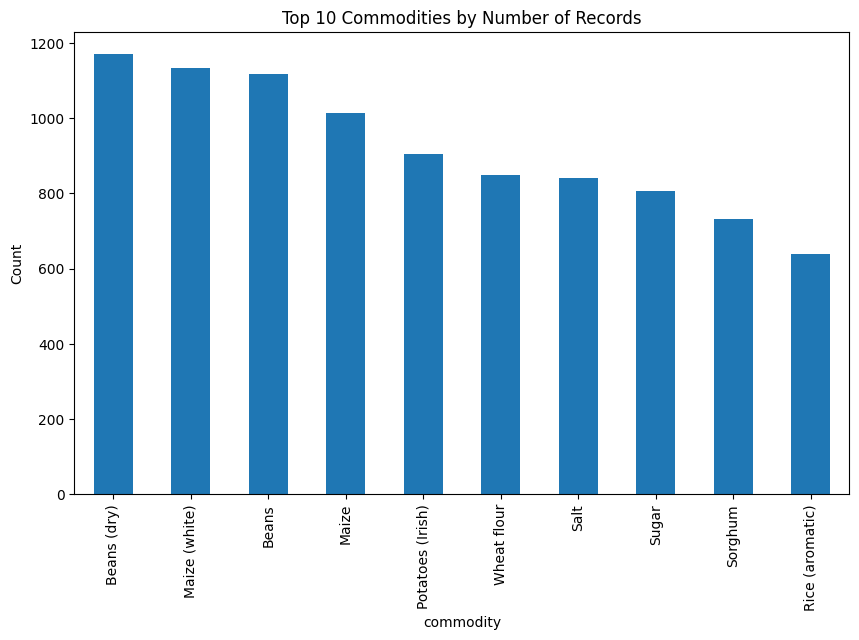

In [9]:
commodity_counts = df["commodity"].value_counts().head(10)

commodity_counts.plot(
    kind="bar",
    figsize=(10,6),
    title="Top 10 Commodities by Number of Records"
)
plt.ylabel("Count")
plt.show()

In [8]:
df["commodity"].value_counts()

commodity
Beans (dry)                   1171
Maize (white)                 1133
Beans                         1117
Maize                         1014
Potatoes (Irish)               905
Wheat flour                    848
Salt                           841
Sugar                          807
Sorghum                        731
Rice (aromatic)                639
Maize (white, dry)             611
Oil (vegetable)                516
Kale                           514
Milk (cow, pasteurized)        504
Oil (vegetable, fortified)     446
Maize flour (white)            438
Rice                           434
Maize flour                    412
Milk (UHT)                     392
Bananas                        353
Cabbage                        320
Onions (dry)                   309
Tomatoes                       288
Potatoes (Irish, white)        273
Beans (yellow)                 261
Meat (goat)                    255
Meat (beef)                    224
Spinach                        203
Cowpeas   

Average Price by Commodity

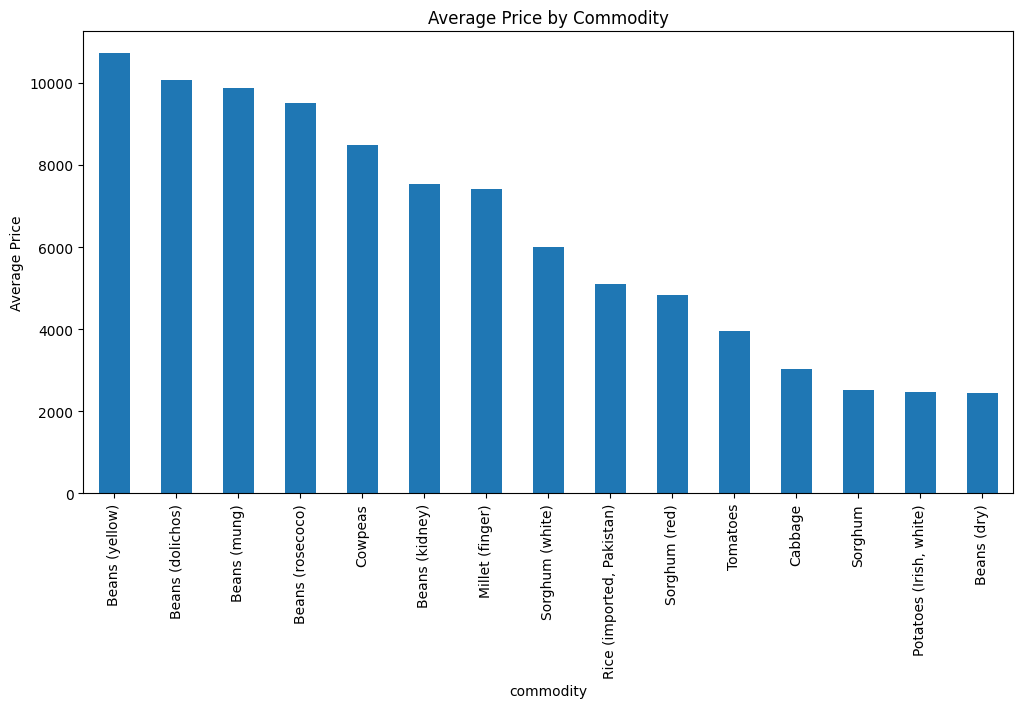

In [10]:
avg_price = (
    df.groupby("commodity")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

avg_price.plot(kind="bar", figsize=(12,6))
plt.title("Average Price by Commodity")
plt.ylabel("Average Price")
plt.show()

Price Trend Over Time : Maize

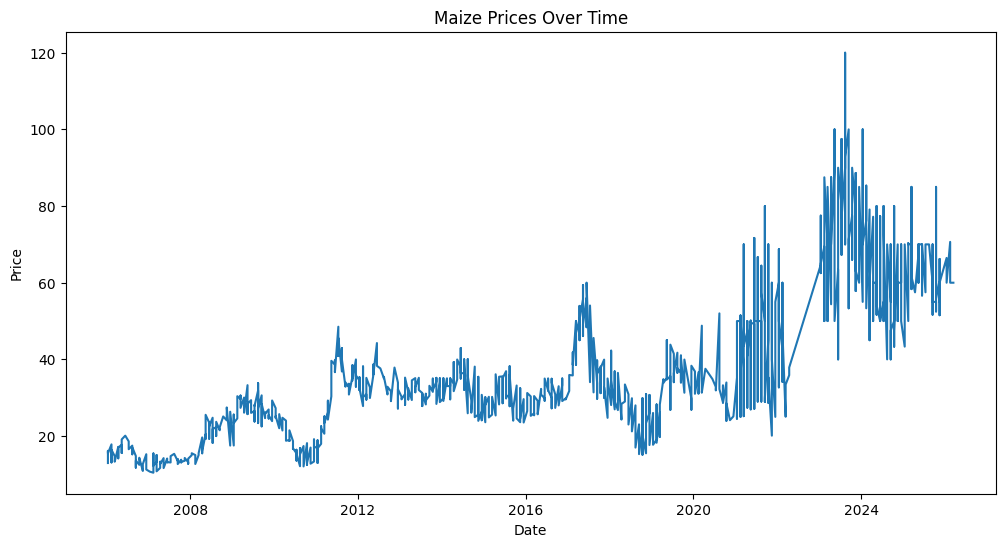

In [7]:
import matplotlib.pyplot as plt

maize = df[df['commodity'] == 'Maize']

plt.figure(figsize=(12,6))
plt.plot(maize['date'], maize['price'])
plt.title('Maize Prices Over Time')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()

Top Markets

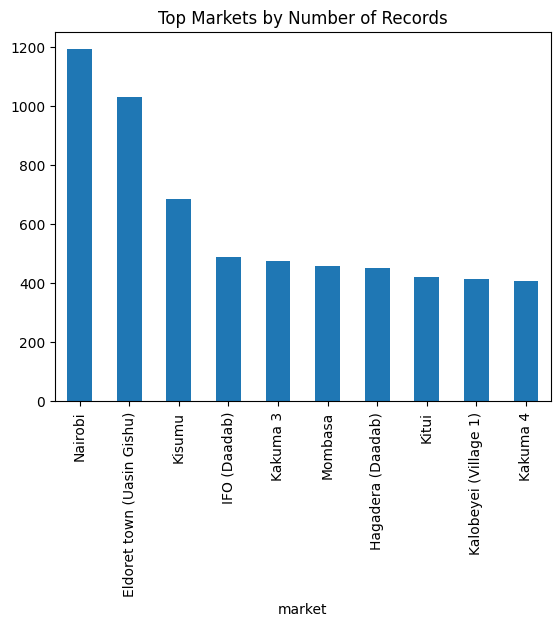

In [11]:
market_counts = df["market"].value_counts().head(10)

market_counts.plot(kind="bar")
plt.title("Top Markets by Number of Records")
plt.show()

Price Distribution

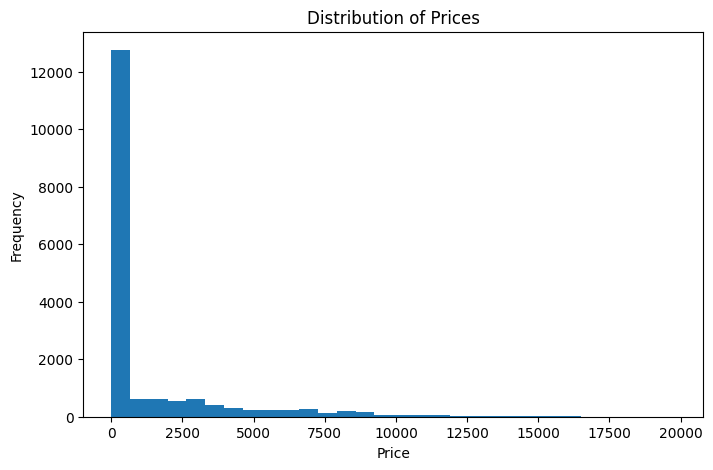

In [12]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=30)
plt.title("Distribution of Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**What the chart shows:**
- Most observations are concentrated at lower prices (the very tall bar on the left).
- A small number of observations have very high prices, stretching all the way toward 20,000.
- The distribution is heavily right-skewed (long tail to the right).

**Interpretation**

- The distribution of food prices is highly positively skewed, with the majority of observations concentrated at lower price levels and a small number of observations occurring at substantially higher prices.
- This suggests considerable variation in food commodity prices across markets and commodity types. The presence of extreme values may be attributed to differences in commodity categories, units of measurement, or market conditions.

Commodity Price Variability (Boxplot)

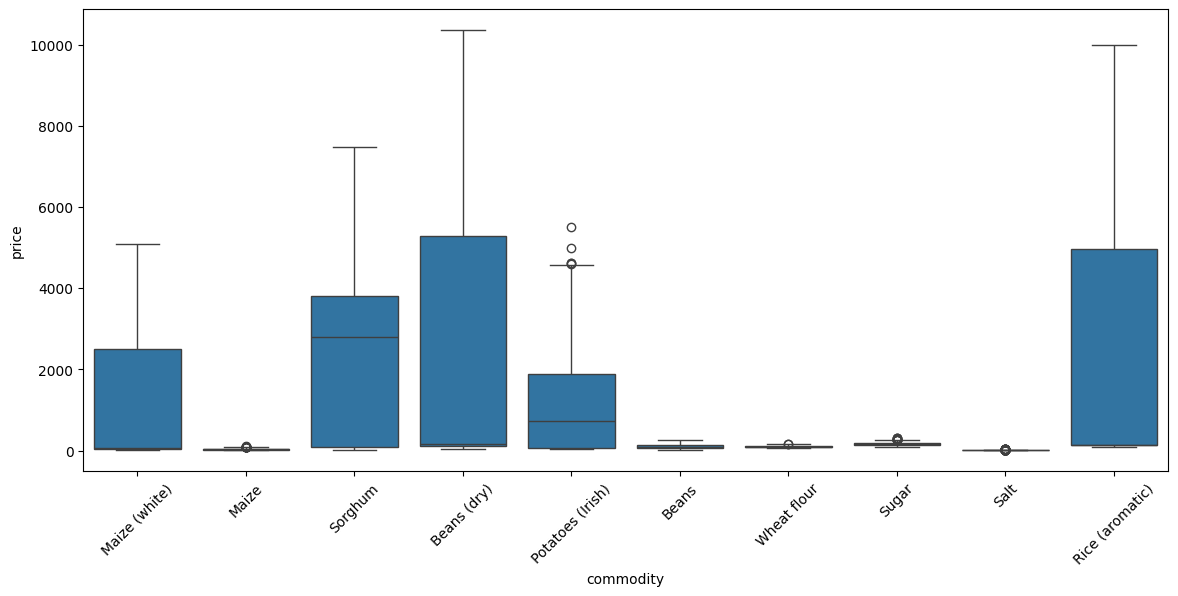

In [14]:
import seaborn as sns
top_10 = df["commodity"].value_counts().head(10).index
plt.figure(figsize=(14,6))

sns.boxplot(
    data=df[df["commodity"].isin(top_10)],
    x="commodity",
    y="price"
)

plt.xticks(rotation=45)
plt.show()

Market comparison

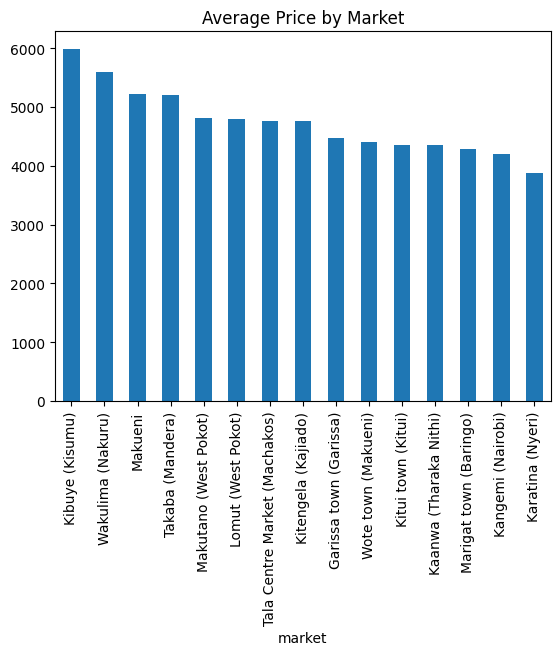

In [15]:
market_avg = (
    df.groupby("market")["price"]
      .mean()
      .sort_values(ascending=False)
      .head(15)
)

market_avg.plot(kind="bar")
plt.title("Average Price by Market")
plt.show()

Monthly seasonality

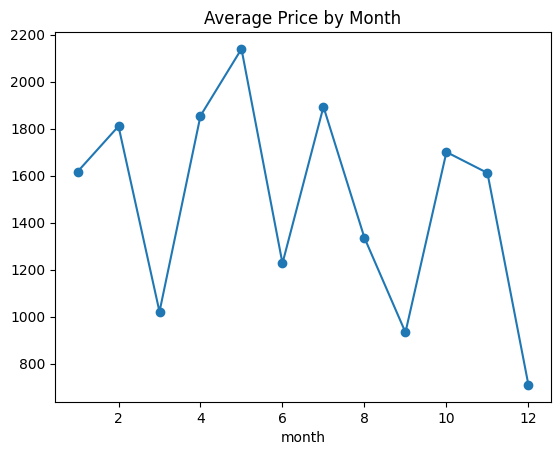

In [16]:
df["month"] = df["date"].dt.month

monthly_avg = (
    df.groupby("month")["price"]
      .mean()
)

monthly_avg.plot(marker="o")
plt.title("Average Price by Month")
plt.show()

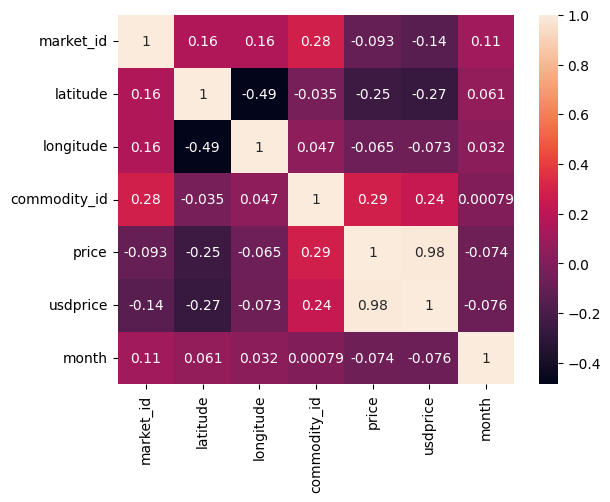

In [18]:
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()